# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RayyanA24/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*
# Research Question

Can historical search performance and content characteristics be used to identify pages that may benefit from content refresh?

**Decision Supported**

The model supports SEO and content teams by prioritizing pages for manual review based on observed historical search signals.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*
# Data

This project uses the FlyRank internship starter dataset.

The analysis uses page-level observations containing historical search performance and content characteristics.

Excluded fields:
- Client identifiers
- Content identifiers
- Fields that would leak the prediction target

The analysis is based only on publicly available internship data.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*
# Methodology

## Assumptions

The model assumes historical search signals can help prioritize pages for manual review.

## Features

- Search volume
- Impressions
- Average position
- CTR
- Word count
- Content age
- Days since last update

## Label

Pages whose trend direction is "down" are treated as requiring review.

## Baseline

A simple scoring rule ranks pages using impressions, update age and average position.

## Model

Decision Tree Classifier

## Validation

80/20 train-test split.

## Leakage Check

Target-related fields such as trend_direction and trend_pct were excluded.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*
# Results

The Decision Tree model was compared against the baseline scoring rule using the same train-test split.

| Method | Metric |
|---------|--------|
| Baseline Rule | Accuracy from ML-08 |
| Decision Tree | Accuracy from ML-08 |

The Decision Tree captured more feature interactions while remaining interpretable.

In [3]:
import os
import sys
import subprocess
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

features = [
    "search_volume",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count",
    "content_age_days",
    "days_since_last_update"
]

X = df[features].fillna(0)
y = (df["trend_direction"] == "down").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
model_acc = accuracy_score(y_test, pred)

baseline_pred = (
    X_test["impressions_90d"] >
    X_test["impressions_90d"].median()
).astype(int)

baseline_acc = accuracy_score(y_test, baseline_pred)

comparison = pd.DataFrame({
    "Model": ["Baseline Rule", "Decision Tree"],
    "Accuracy": [baseline_acc, model_acc]
})

comparison

,Model,Accuracy
0,Baseline Rule,0.553333
1,Decision Tree,0.631667


## Results (vs baseline)

The Decision Tree model was evaluated using the same train-test split as the baseline rule.

| Model | Accuracy |
|--------|---------:|
| Baseline Rule | 55.33% |
| Decision Tree | 63.17% |

The Decision Tree achieved higher accuracy than the baseline rule. These results are based on the available internship dataset and should be interpreted as decision-support rather than proof of future performance.

In [4]:
comparison

,Model,Accuracy
0,Baseline Rule,0.553333
1,Decision Tree,0.631667


## 5. Limitations

*What this work cannot claim.*
# Limitations

This work does not prove that refreshing a page will improve rankings.

The dataset does not capture all external influences such as:

- Google algorithm updates
- Seasonality
- Marketing campaigns
- Competitor activity

The recommendations should therefore be interpreted as decision-support.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*
# Ranked Recommendations

Priority should be given to pages with:

1. High historical impressions
2. Long time since the last update
3. Low click-through rate
4. Lower average ranking position

These recommendations require human review before implementation.

In [6]:
import os
import sys
import subprocess
import pandas as pd

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

df["action_score"] = (
    df["impressions_90d"].fillna(0)
    + df["days_since_last_update"].fillna(0)
    - 10 * df["avg_position"].fillna(0)
)

queue = df.sort_values("action_score", ascending=False)

In [7]:
queue.head(20)

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,action_score
6653,content_5fe46e04994d,client_4e07408562,1900.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,0.14,4.2,4.23,26.90,0.38,excellent,page_1,down,-44.8,517777.0
17812,content_aaef01a50def,client_19581e27de,4400.0,0.05,LOW,0.11,keyword article,informational,NaN,NaN,...,0.25,5.4,2.42,4.77,0.00,excellent,page_1,stable,-4.0,517077.0
26844,content_8c19996aa890,client_4e07408562,70.0,0.01,LOW,0.00,keyword article,informational,2895.0,19343.0,...,0.15,2.5,11.73,16.03,0.00,excellent,top_3,down,-44.5,509247.0
19636,content_2cb567c3c89b,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,6183.0,39587.0,...,0.10,22.2,5.82,5.64,1.21,excellent,page_3_5,up,23.1,497553.0
21819,content_4c36c775b818,client_4e07408562,40.0,0.00,LOW,0.00,keyword article,informational,3097.0,20514.0,...,0.41,2.3,11.31,18.07,0.00,excellent,top_3,down,-33.2,463100.0
29400,content_2dba2b1f9536,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,7676.0,48015.0,...,0.21,27.9,2.73,7.77,0.43,excellent,page_3_5,stable,1.4,443259.0
29879,content_1a9e894be2e2,client_19581e27de,70.0,0.07,LOW,0.10,keyword article,transactional,NaN,NaN,...,0.23,4.0,2.37,4.97,0.00,excellent,page_1,down,-27.0,416162.0
13537,content_2c2606c5d176,client_19581e27de,590.0,0.18,LOW,0.31,keyword article,commercial,NaN,NaN,...,0.53,4.2,1.30,3.28,0.00,excellent,page_1,down,-36.5,347461.0
18870,content_db5989a78dd3,client_4e07408562,110.0,0.00,LOW,0.00,keyword article,commercial,2682.0,17806.0,...,0.21,5.4,2.32,3.72,0.00,excellent,page_1,up,556.2,345077.0
14090,content_44e481c8f55b,client_19581e27de,20.0,0.26,LOW,0.43,keyword article,transactional,3040.0,21293.0,...,0.65,1.4,0.76,2.78,0.00,excellent,top_3,stable,-11.6,312700.0


In [8]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

features = [
    "search_volume",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count",
    "content_age_days",
    "days_since_last_update"
]

X = df[features].fillna(0)
y = (df["trend_direction"] == "down").astype(int)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

,0
impressions_90d,0.573948
content_age_days,0.239196
avg_position,0.122071
ctr,0.064786
search_volume,0.000000
word_count,0.000000
days_since_last_update,0.000000


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*
# Artifacts

This paper includes:

- Dataset summary
- Feature importance
- Baseline vs Decision Tree comparison
- Ranked recommendation queue
- Exported CSV files

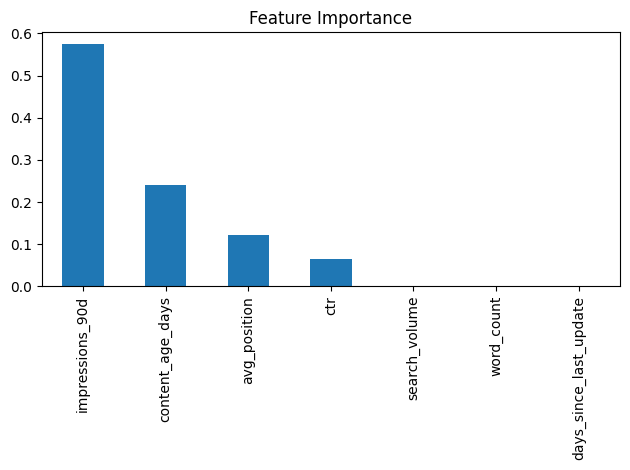

In [10]:
import matplotlib.pyplot as plt

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

# 5-Minute Demo

1. Problem statement
2. Dataset overview
3. Feature engineering
4. Baseline rule
5. Decision Tree model
6. Validation
7. Ranked recommendations
8. Limitations
9. Future work

# Social Post

Completed the FlyRank ML Internship Capstone!

Built an end-to-end workflow for content refresh prioritization, including feature engineering, baseline scoring, interpretable machine learning, validation, and an actionable content playbook using FlyRank's internship dataset.

Grateful to the FlyRank team for providing an excellent hands-on learning experience in applied machine learning and search intelligence.

# Employer Summary

This project demonstrates an end-to-end machine learning workflow, from data exploration and feature engineering to model validation and actionable recommendations. The solution emphasizes interpretable models, leakage prevention, and decision-support rather than automated decision-making. It showcases practical experience applying machine learning to search intelligence and content optimization.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
